# 03 — Graph Neural Network: Multi-Sensor Spatio-Temporal Graphs

Phases 1-2 only used the drive-end (DE) accelerometer channel. CWRU also records a fan-end
(FE) channel on every file (including `Normal`), so Phase 3 uses **both** to build a genuine
multi-sensor graph per window, per [docs/datasets.md](../docs/datasets.md):

- **Nodes**: each window is split into 8 time segments per channel -> 16 nodes (2 channels x 8
  segments), each with 10 time-domain features (`src/data/features.py`).
- **Edges**: temporal (segment *i* <-> *i+1* within a channel) + cross-channel coupling (DE
  segment *i* <-> FE segment *i*, since both accelerometers ride the same shaft assembly).
- **Model**: a 3-layer GCN (`src/models/gnn.py`) + global mean pooling + linear classifier.

Same held-out-load evaluation protocol as Phase 2 (train loads 0-2, test load 3), so results
are directly comparable to the Random Forest / SVM / 1D CNN / autoencoder numbers from
[docs/phase2_results.md](../docs/phase2_results.md).


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch_geometric.loader import DataLoader

from src.data.cwru import build_multichannel_windowed_dataset
from src.data.graph_utils import build_graph_dataset, compute_node_feature_stats, N_NODE_FEATURES
from src.models.baseline import time_contiguous_split
from src.models.gnn import GcnClassifier, train_gnn, predict

CWRU_DIR = Path.cwd().parent / "data" / "raw" / "cwru"
WINDOW_SIZE = 2048
N_SEGMENTS = 8
TEST_LOAD = 3
torch.manual_seed(42)
np.random.seed(42)


C:\Gabriel Claude\fault-detection-engine-parts\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Load DE+FE aligned windows and split by held-out load

In [2]:
channel_windows, labels, loads, file_ids = build_multichannel_windowed_dataset(
    CWRU_DIR, window_size=WINDOW_SIZE, channels=("DE", "FE")
)
de_windows, fe_windows = channel_windows["DE"], channel_windows["FE"]
print("windows:", de_windows.shape, fe_windows.shape)
print(pd.crosstab(labels, loads))


windows: (2953, 2048) (2953, 2048)
col_0     0    1    2    3
row_0                     
B007     59   59   59   59
B014     59   59   59   59
B021     59   59   59   59
IR007    59   59   59   60
IR014    59   59   59   59
IR021    59   59   59   59
Normal  119  236  236  237
OR007    59   59   59   59
OR014    59   59   59   59
OR021    59   59   59   59


In [3]:
train_mask = loads != TEST_LOAD
test_mask = loads == TEST_LOAD
inner_train_mask, inner_val_mask = time_contiguous_split(file_ids[train_mask], test_fraction=0.15)

le = LabelEncoder()
y_all = le.fit_transform(labels)
class_names = le.classes_

de_train, fe_train = de_windows[train_mask][inner_train_mask], fe_windows[train_mask][inner_train_mask]
de_val, fe_val = de_windows[train_mask][inner_val_mask], fe_windows[train_mask][inner_val_mask]
de_test, fe_test = de_windows[test_mask], fe_windows[test_mask]

y_train = y_all[train_mask][inner_train_mask]
y_val = y_all[train_mask][inner_val_mask]
y_test = y_all[test_mask]

print("train:", len(y_train), "val:", len(y_val), "test:", len(y_test))


train: 1853 val: 331 test: 769


## Build per-window graphs

In [4]:
feature_mean, feature_std = compute_node_feature_stats(de_train, fe_train, N_SEGMENTS)

train_graphs = build_graph_dataset(de_train, fe_train, y_train, N_SEGMENTS, feature_mean, feature_std)
val_graphs = build_graph_dataset(de_val, fe_val, y_val, N_SEGMENTS, feature_mean, feature_std)
test_graphs = build_graph_dataset(de_test, fe_test, y_test, N_SEGMENTS, feature_mean, feature_std)

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=64)
test_loader = DataLoader(test_graphs, batch_size=64)

print("one graph: nodes x features =", train_graphs[0].x.shape, "| edges =", train_graphs[0].edge_index.shape)


one graph: nodes x features = torch.Size([16, 21]) | edges = torch.Size([2, 44])


## Train the GCN

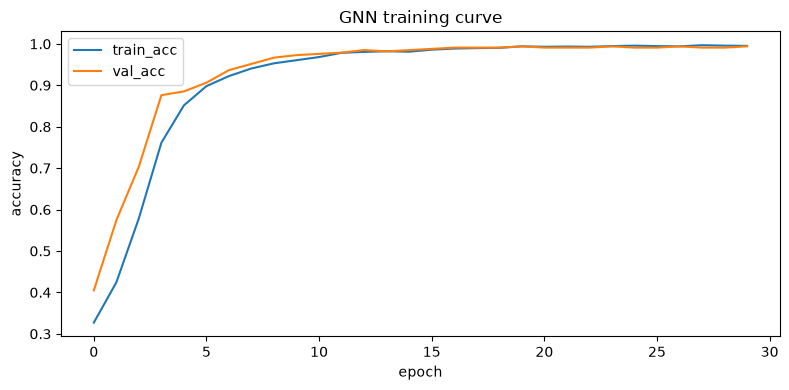

,epoch,train_loss,train_acc,val_loss,val_acc
25,25,0.024654,0.994603,0.028228,0.990937
26,26,0.023261,0.994064,0.023922,0.993958
27,27,0.022925,0.996762,0.029234,0.990937
28,28,0.021022,0.995683,0.026402,0.990937
29,29,0.018318,0.995143,0.019544,0.993958


In [5]:
gnn_model = GcnClassifier(num_node_features=N_NODE_FEATURES, num_classes=len(class_names))
history = train_gnn(gnn_model, train_loader, val_loader, epochs=30, lr=1e-3)

history_df = pd.DataFrame(history)
history_df[["train_acc", "val_acc"]].plot(figsize=(8, 4), title="GNN training curve")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.tight_layout()
plt.show()
history_df.tail()


## Evaluate on held-out load 3

In [6]:
gnn_preds, gnn_targets = predict(gnn_model, test_loader)
gnn_pred_labels = le.inverse_transform(gnn_preds)
gnn_true_labels = le.inverse_transform(gnn_targets)

print(classification_report(gnn_true_labels, gnn_pred_labels, zero_division=0))
gnn_accuracy = (gnn_preds == gnn_targets).mean()
print(f"GNN held-out-load accuracy: {gnn_accuracy:.3f}")


              precision    recall  f1-score   support

        B007       0.67      1.00      0.80        59
        B014       0.68      0.73      0.70        59
        B021       0.35      0.34      0.34        59
       IR007       1.00      1.00      1.00        60
       IR014       1.00      0.88      0.94        59
       IR021       1.00      1.00      1.00        59
      Normal       0.95      1.00      0.97       237
       OR007       1.00      1.00      1.00        59
       OR014       1.00      0.37      0.54        59
       OR021       1.00      1.00      1.00        59

    accuracy                           0.87       769
   macro avg       0.87      0.83      0.83       769
weighted avg       0.88      0.87      0.86       769

GNN held-out-load accuracy: 0.871


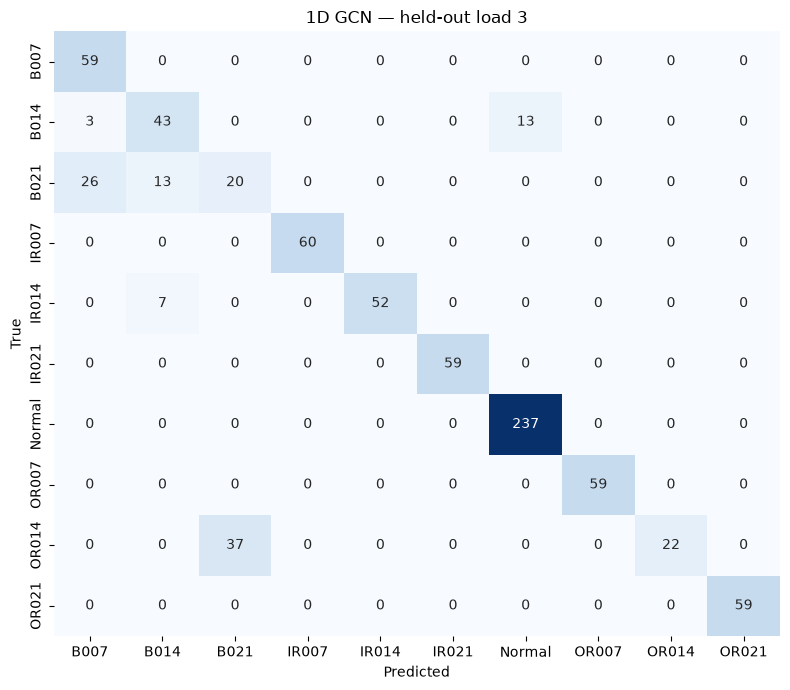

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(gnn_true_labels, gnn_pred_labels, labels=class_names)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
ax.set_title("1D GCN — held-out load 3")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "phase3_confusion_matrix.png", dpi=150)
plt.show()


## Comparison with Phase 1 & 2

Same held-out-load-3 split, same 10 classes. Phase 1/2 numbers are copied in from
[docs/phase2_results.md](../docs/phase2_results.md) (re-running those notebooks would
reproduce them, since all splits/seeds are fixed).


In [8]:
summary = pd.DataFrame([
    {"model": "Random Forest (classical, Phase 2)", "accuracy": 0.978},
    {"model": "SVM (classical, Phase 2)", "accuracy": 0.831},
    {"model": "1D CNN (Phase 2)", "accuracy": 0.918},
    {"model": "GCN, DE+FE spatio-temporal graph (Phase 3)", "accuracy": gnn_accuracy},
]).sort_values("accuracy", ascending=False).reset_index(drop=True)
summary


,model,accuracy
0,"Random Forest (classical, Phase 2)",0.978000
1,1D CNN (Phase 2),0.918000
2,"GCN, DE+FE spatio-temporal graph (Phase 3)",0.871261
3,"SVM (classical, Phase 2)",0.831000
